# ENIAC — Discount Analysis




In [ ]:
import pandas as pd

# orders_qu.csv
url = "https://drive.google.com/file/d/1gQEV49nHCzeJ2iYhjFSJBgEsjT2AujSv/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_qu = pd.read_csv(path)

# orderlines_qu.csv
url = "https://drive.google.com/file/d/1nOfZA34PkdA2snnmWf4zMFW468a7yT4C/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_qu = pd.read_csv(path)

# products_qu.csv
url = "https://drive.google.com/file/d/1snD2fb30DVcZhxuo-ojoFoX5ERoHghU4/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_qu = pd.read_csv(path)

# brands_cl.csv
url = "https://drive.google.com/file/d/1tTonvQ_Ja3s4OPoo2J4apK4D2ZTI8unH/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands_cl = pd.read_csv(path)


In [ ]:
product_category_df = products_qu.copy()

## Are discounts widely used at ENIAC?


In [ ]:
# How many PRODUCTS (distinct SKU) are discounted?
total_products = product_category_df["sku"].nunique()
total_products

9992

In [ ]:
# merging orderlines and products
prod_ol_df = orderlines_qu.merge(product_category_df, on="sku", how="left")
prod_ol_df

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,brand,category
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1,12755395,OWC,smart_home
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0,5720,IOT,accessory
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1,13005399,APP,accessory
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0,1298,CRU,accessory
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,0,11905404,PEB,wearable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory


Creating new column discount

In [ ]:
# creating new column "discount"
prod_ol_df["discount"] = prod_ol_df.price - prod_ol_df.unit_price
prod_ol_df

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,brand,category,discount
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1,12755395,OWC,smart_home,13.50
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0,5720,IOT,accessory,3.96
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1,13005399,APP,accessory,16.81
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0,1298,CRU,accessory,16.09
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,0,11905404,PEB,wearable,157.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,15.01
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,15.01
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,15.01
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,15.01


In [ ]:
prod_ol_df.discount.describe()

,discount
count,53231.000000
mean,26.116673
std,45.545881
min,-170.990000
25%,5.250000
50%,15.000000
75%,31.000000
max,1320.000000


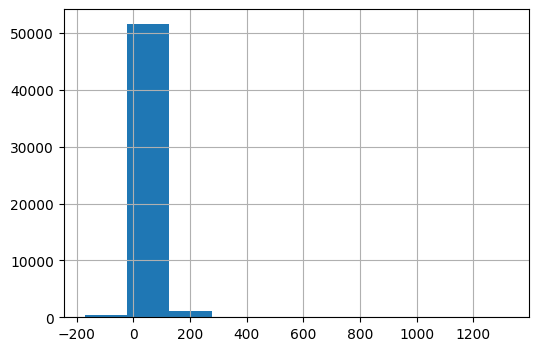

In [ ]:
# histogram of discount
prod_ol_df.discount.hist(figsize=(6,4));

Creating new column %_discount

In [ ]:
# creating new column "%_discount"
prod_ol_df["discount_pct"] = (prod_ol_df.discount / prod_ol_df.price) * 100
prod_ol_df.head(1)

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,brand,category,discount,discount_pct
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1,12755395,OWC,smart_home,13.5,22.134776


In [ ]:
discounted_products = prod_ol_df.loc[prod_ol_df["discount_pct"] > 0, "sku"].nunique()
discounted_products

4906

In [ ]:
non_discounted_products = total_products - discounted_products

total_products, discounted_products, non_discounted_products



(9992, 4906, 5086)

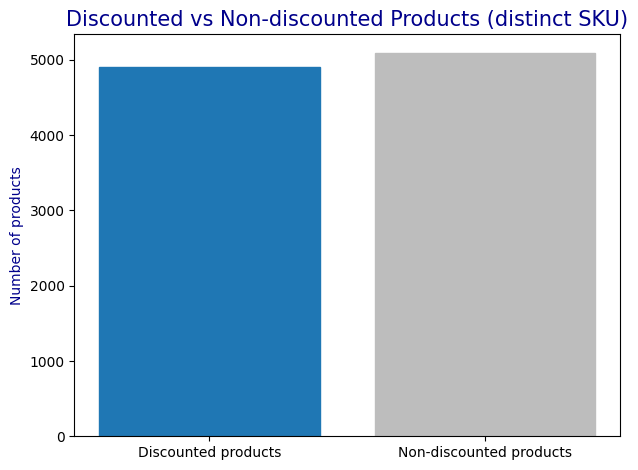

In [ ]:
products_summary = pd.DataFrame({
    "Product type": ["Discounted products", "Non-discounted products"],
    "Count": [discounted_products, non_discounted_products]
})

products_summary
import matplotlib.pyplot as plt

# Plot with individual bar colors
fig, ax = plt.subplots()

bars = ax.bar(
    products_summary["Product type"],
    products_summary["Count"]
)

# Set colors manually
bars[0].set_color("#1f77b4")   # blue → discounted
bars[1].set_color("#bdbdbd")   # grey → non-discounted

ax.set_title("Discounted vs Non-discounted Products (distinct SKU)",color="darkblue", fontsize = 15)
ax.set_ylabel("Number of products", color="darkblue", fontsize = 10)
ax.set_xlabel("")

plt.tight_layout()
plt.show()

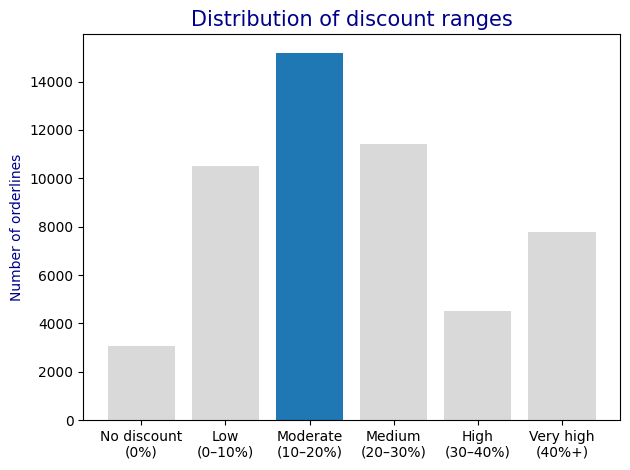

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

bins = [-1, 0, 10, 20, 30, 40, 100]
labels = ["0%", "0–10%", "10–20%", "20–30%", "30–40%", "40%+"]
prod_ol_df['discount_range'] = pd.cut(prod_ol_df['discount_pct'], bins=bins, labels=labels)
discount_distribution = prod_ol_df['discount_range'].value_counts()
# Order and business labels
order = ["0%", "0–10%", "10–20%", "20–30%", "30–40%", "40%+"]
business_labels = [
    "No discount\n(0%)",
    "Low\n(0–10%)",
    "Moderate\n(10–20%)",
    "Medium\n(20–30%)",
    "High\n(30–40%)",
    "Very high\n(40%+)"
]

dist = discount_distribution.reindex(order)

# Highlight Moderate (10–20%) in blue
colors = ["#d9d9d9", "#d9d9d9", "#1f77b4", "#d9d9d9", "#d9d9d9", "#d9d9d9"]

fig, ax = plt.subplots()
ax.bar(range(len(dist)), dist.values, color=colors)

ax.set_title("Distribution of discount ranges",color="darkblue", fontsize = 15)
ax.set_ylabel("Number of orderlines",color="darkblue", fontsize = 10)

# Apply business labels
ax.set_xticks(range(len(order)))
ax.set_xticklabels(business_labels)

plt.tight_layout()
plt.show()


Most orderlines fall within the moderate discount range, making it the most frequently used discount level across all transactions.

Low discounts are also widely applied, suggesting that small price reductions are a common tactic to stimulate purchases.

Orders without any discount represent a relatively small share, indicating that discounting is a standard practice rather than an exception.

High discount ranges (30% and above) are less frequent, showing that aggressive discounting is used selectively rather than as a regular strategy.

## Do higher discounts increase revenue? How does discounts impact margins?

In [ ]:
# Merge orderlines (+ products df) with orders
sales_df = prod_ol_df.merge(
    orders_qu[["order_id", "created_date"]],
    left_on="id_order",     # in orderlines/df
    right_on="order_id",    # in orders
    how="left"
)

# Convert date
sales_df["created_date"] = pd.to_datetime(sales_df["created_date"])

# Create month
sales_df["month"] = sales_df["created_date"].dt.to_period("M").astype(str)

sales_df[["id_order", "order_id", "created_date", "month"]].head()


,id_order,order_id,created_date,month
0,299545,299545,2017-01-01 01:51:47,2017-01
1,299546,299546,2017-01-01 01:57:34,2017-01
2,295347,295347,2017-01-01 02:02:38,2017-01
3,299556,299556,2017-01-01 02:30:08,2017-01
4,299561,299561,2017-01-01 02:39:47,2017-01


In [ ]:
sales_df["revenue"] = (
    sales_df["unit_price"] * sales_df["product_quantity"]
)
sales_df["month"] = sales_df["created_date"].dt.to_period("M")
sales_df

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,...,type,brand,category,discount,discount_pct,discount_range,order_id,created_date,month,revenue
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,...,12755395,OWC,smart_home,13.50,22.134776,20–30%,299545,2017-01-01 01:51:47,2017-01,47.49
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,...,5720,IOT,accessory,3.96,17.254902,10–20%,299546,2017-01-01 01:57:34,2017-01,18.99
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,...,13005399,APP,accessory,16.81,18.887640,10–20%,295347,2017-01-01 02:02:38,2017-01,72.19
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,...,1298,CRU,accessory,16.09,20.898818,20–30%,299556,2017-01-01 02:30:08,2017-01,60.90
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,...,11905404,PEB,wearable,157.50,52.501750,40%+,299561,2017-01-01 02:39:47,2017-01,142.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,...,1230,APP,accessory,15.01,60.040000,40%+,527035,2018-03-14 11:44:34,2018-03,9.99
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,...,1230,APP,accessory,15.01,60.040000,40%+,527070,2018-03-14 11:50:48,2018-03,19.98
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,...,1230,APP,accessory,15.01,60.040000,40%+,527074,2018-03-14 11:51:42,2018-03,19.98
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,...,1230,APP,accessory,15.01,60.040000,40%+,527096,2018-03-14 11:58:40,2018-03,29.97


In [ ]:
Eniac_monthly_revenue = (
    sales_df
    .groupby("month")["revenue"]
    .sum()
    .round(1)
    .reset_index()
)

Eniac_monthly_revenue

,month,revenue
0,2017-01,604091.9
1,2017-02,332612.3
2,2017-03,24856.0
3,2017-04,228090.6
4,2017-05,331215.0
5,2017-06,286575.7
6,2017-07,599404.9
7,2017-08,379560.3
8,2017-09,387942.8
9,2017-10,547599.6


In [ ]:
sales_df["margin_ratio"] = (
    sales_df["unit_price"] / sales_df["price"]
)

In [ ]:
margin_by_discount_range = (
    sales_df
    .groupby("discount_range")["margin_ratio"]
    .mean()
    .reset_index()
)

margin_by_discount_range


/tmp/ipykernel_5619/1469768653.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("discount_range")["margin_ratio"]


,discount_range,margin_ratio
0,0%,1.000605
1,0–10%,0.945449
2,10–20%,0.851790
3,20–30%,0.758217
4,30–40%,0.660485
5,40%+,0.438518


In [ ]:
discount_impact = (
    sales_df
    .groupby("discount_range")
    .agg(
        Total_Revenue=("revenue", "sum"),
        Avg_Margin_Ratio=("margin_ratio", "mean")
    )
    .reset_index()
)
discount_impact

/tmp/ipykernel_5619/2438508569.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("discount_range")


,discount_range,Total_Revenue,Avg_Margin_Ratio
0,0%,319867.71,1.000605
1,0–10%,2647204.05,0.945449
2,10–20%,2546320.72,0.851790
3,20–30%,1442741.84,0.758217
4,30–40%,337477.84,0.660485
5,40%+,268378.97,0.438518


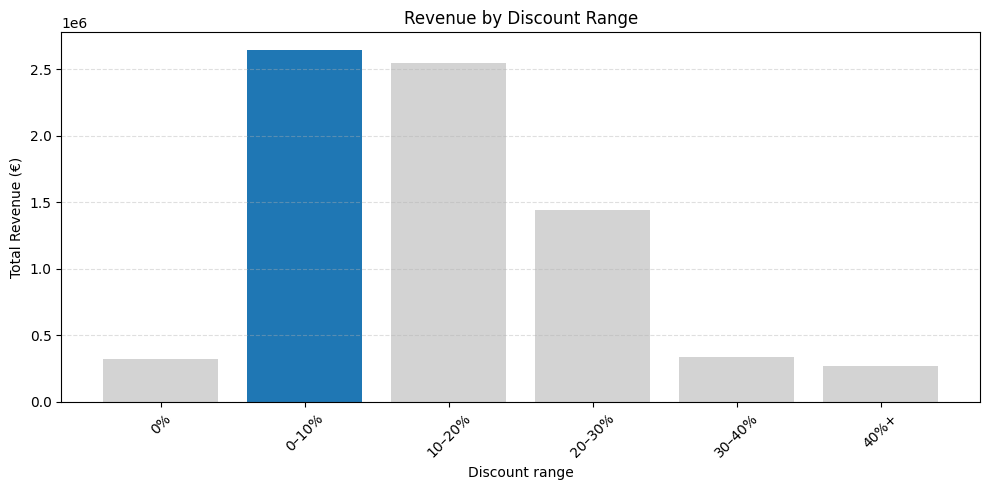

In [ ]:
import matplotlib.pyplot as plt

# Ordre des discount ranges
order = ["0%", "0–10%", "10–20%", "20–30%", "30–40%", "40%+"]

# DF agrégé existant
plot_df = discount_impact.set_index("discount_range").loc[order].reset_index()

# Données en listes
x_labels = plot_df["discount_range"].tolist()
revenue = plot_df["Total_Revenue"].tolist()
#margin = plot_df["Avg_Margin_Ratio"].tolist()

# Couleurs : 0–10% en bleu, le reste en gris
bar_colors = ["lightgrey"] * len(x_labels)
bar_colors[x_labels.index("0–10%")] = "tab:blue"

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Bars = Revenue
ax1.bar(x_labels, revenue, color=bar_colors)
ax1.set_xlabel("Discount range")
ax1.set_ylabel("Total Revenue (€)")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Line = Margin (en rouge)
#ax2 = ax1.twinx()
#ax2.plot(x_labels, margin, marker="o", color="red")
#ax2.set_ylabel("Average Margin Ratio")

plt.title("Revenue by Discount Range")
plt.tight_layout()
plt.show()


0–10% discount range:
✔️ Highest revenue
✔️ Relatively high margin

Above 20% discounts:
❌ Low revenue
❌ Low margin
👉 High-risk zone

## Are sales driven by discounts or seasonality?

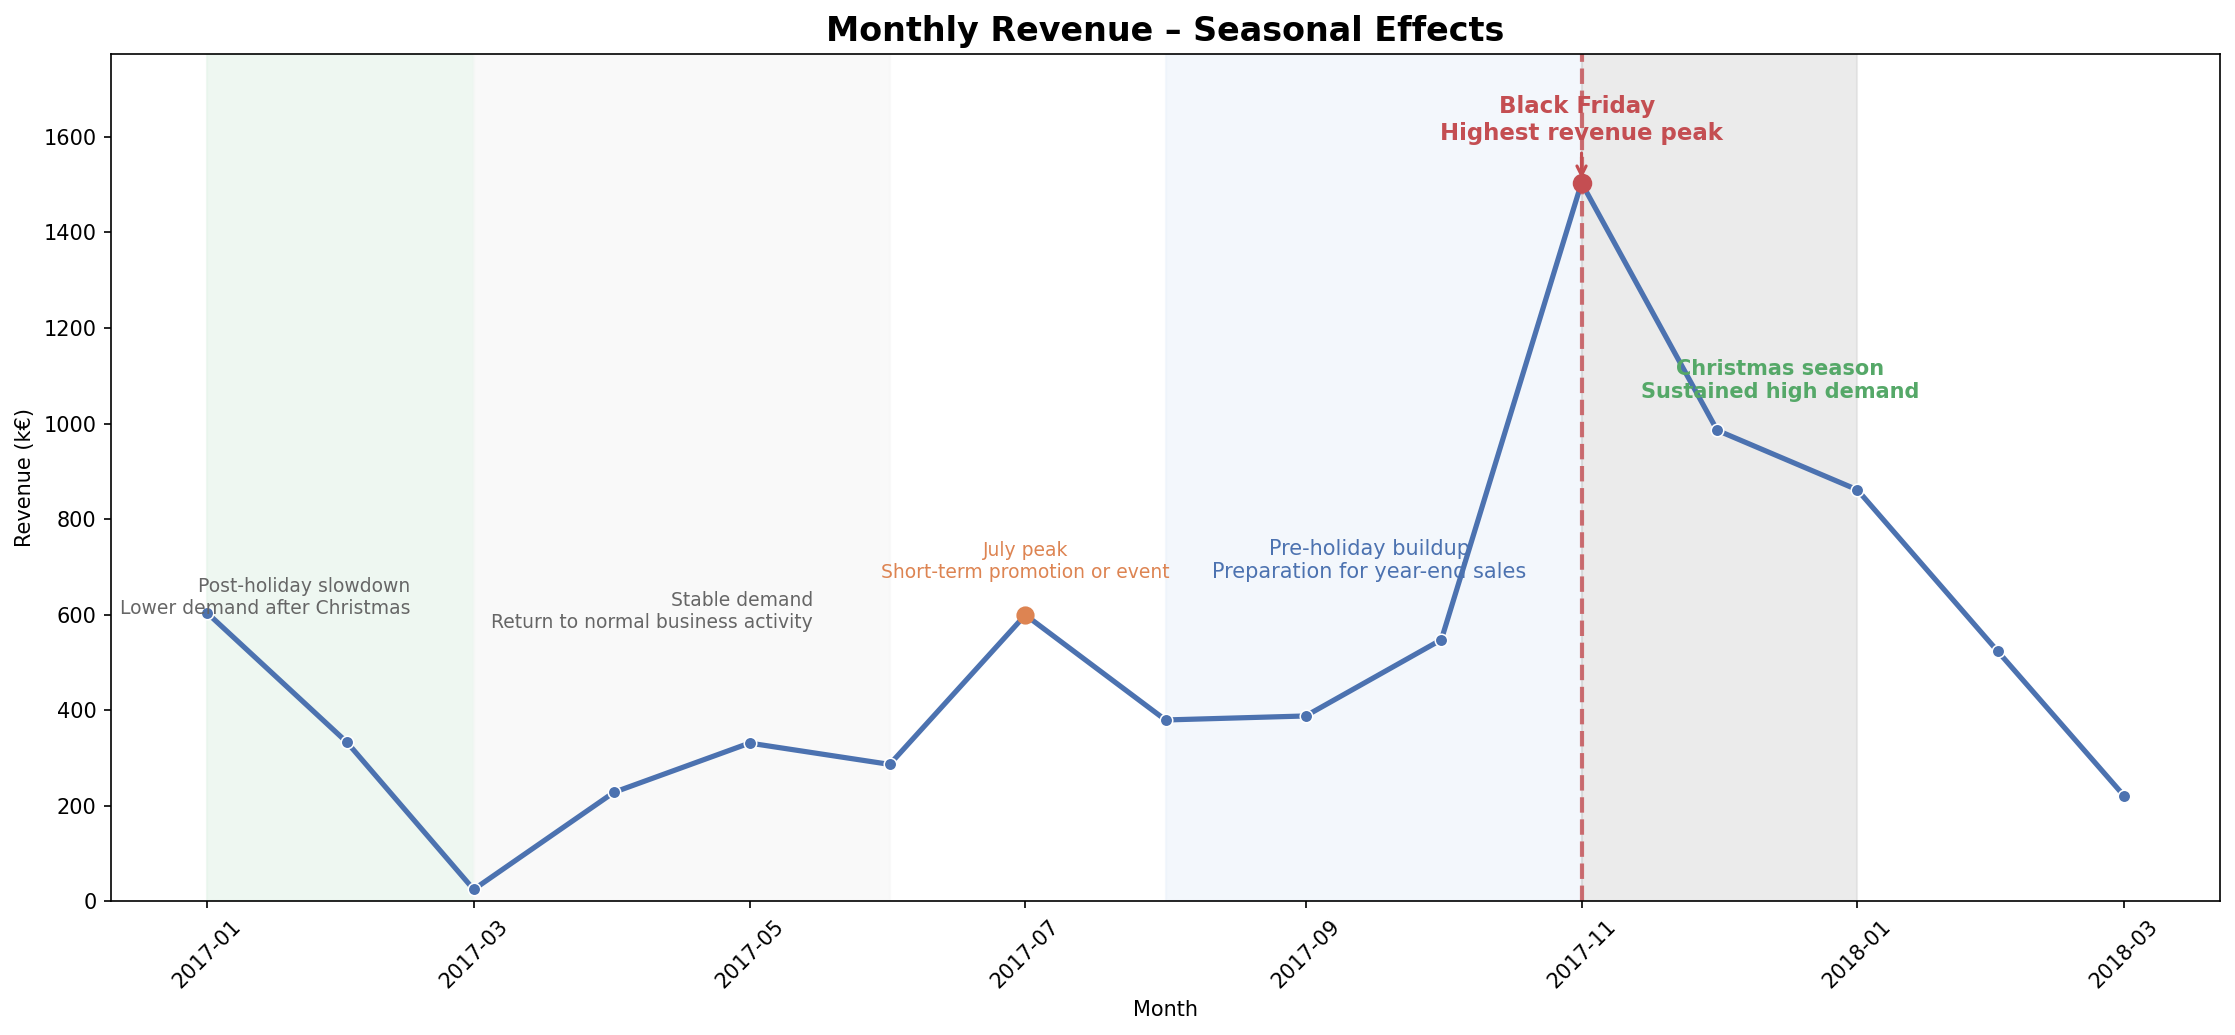

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import FuncFormatter

# 1) Monthly revenue
Eniac_monthly_revenue = (
    sales_df
    .groupby("month")["revenue"]
    .sum()
    .round(1)
    .reset_index()
)

# 2) Convert month to datetime
Eniac_monthly_revenue["month"] = pd.to_datetime(
    Eniac_monthly_revenue["month"].astype(str) + "-01",
    errors="coerce"
)
Eniac_monthly_revenue = Eniac_monthly_revenue.dropna(subset=["month"]).sort_values("month")

T = pd.Timestamp
ymax = Eniac_monthly_revenue["revenue"].max()

# 3) Plot — bigger & sharper
plt.figure(figsize=(15, 7), dpi=150)

sns.lineplot(
    data=Eniac_monthly_revenue,
    x="month",
    y="revenue",
    marker="o",
    linewidth=2.5,
    color="#4C72B0"
)

# Give vertical space for annotations
plt.ylim(0, ymax * 1.18)

# --- Seasonal zones (better calibrated: full month coverage) ---


# Jan–Mar
plt.axvspan(T("2017-01-01"), T("2017-03-01"), color="#e6f4ea", alpha=0.65)
plt.text(
    T("2017-02-15"), ymax * 0.40,
    "Post-holiday slowdown\nLower demand after Christmas",
    ha="right", fontsize=9, color="#666666"
)

# Apr–Jun
plt.axvspan(T("2017-03-01"), T("2017-06-01"), color="#f7f7f7", alpha=0.65)
plt.text(
    T("2017-05-15"), ymax * 0.38,
    "Stable demand\nReturn to normal business activity",
    ha="right", fontsize=9, color="#666666"
)

# Aug–Oct
plt.axvspan(T("2017-08-01"), T("2017-11-01"), color="#eaf2fb", alpha=0.55)
plt.text(
    T("2017-09-15"), ymax * 0.45,
    "Pre-holiday buildup\nPreparation for year-end sales",
    ha="center", fontsize=10, color="#4C72B0"
)

# --- July peak (same annotation text, but peak highlighted) ---
jul_month = T("2017-07-01")
jul_row = Eniac_monthly_revenue.loc[Eniac_monthly_revenue["month"] == jul_month, "revenue"]
if len(jul_row) > 0:
    jul_value = jul_row.values[0]
    # highlight peak (vertical line + point)

    plt.scatter([jul_month], [jul_value], color="#DD8452", zorder=5, s=60)

plt.text(
    T("2017-07-01"), ymax * 0.45,
    "July peak\nShort-term promotion or event",
    ha="center", fontsize=9, color="#DD8452"
)

# --- Black Friday (same annotation text, but period + peak strongly highlighted) ---
bf_month = T("2017-11-01")

# Band just for November (BF / Cyber Monday window)
plt.axvspan(T("2017-11-01"), T("2017-11-01"), color="lightgrey", alpha=0.45)

bf_row = Eniac_monthly_revenue.loc[
    Eniac_monthly_revenue["month"] == bf_month, "revenue"
]
if len(bf_row) > 0:
    bf_value = bf_row.values[0]
    # highlight peak (vertical line + point)
    plt.axvline(bf_month, color="#C44E52", linestyle="--", alpha=0.8, linewidth=2)
    plt.scatter([bf_month], [bf_value], color="#C44E52", zorder=6, s=70)

    plt.annotate(
        "Black Friday \nHighest revenue peak",
        xy=(bf_month, bf_value),
        xytext=(bf_month, ymax * 1.06),
        ha="center",
        fontsize=11,
        color="#C44E52",
        fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="#C44E52", lw=1.5)
    )

# --- Christmas season (same text, but clearer seasonal band) ---
plt.axvspan(T("2017-11-01"), T("2018-01-01"), color="lightgrey", alpha=0.45)
plt.text(
    T("2017-12-15"), ymax * 0.70,
    "Christmas season\nSustained high demand",
    ha="center", fontsize=10, color="#55A868", fontweight="bold"
)

# --- Formatting ---
plt.title("Eniac Monthly Revenue – Seasonal Effects", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (k€)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1000)}")
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## Conclusion & Business Recommendations

- Low discounts (0–20%) generate the highest and most stable revenue
- High discounts increase order volume but reduce margins
- Revenue peaks are driven by seasonal events (Black Friday, Christmas)
- Discounts should be used strategically, not permanently

Recommended strategy:
- Implement discount caps: Discounts at below 20%
- Premium productsare less price-sensitive
- Implement other promotional offers during the seasonal sales (free delivery, offer an accessory when purchasing over a certain amount, ...)
- Improve data collection to support long-term decision making!
